In [1]:
import os
import pandas as pd

project_root = ".."

input_csv = os.path.join(
    project_root,
    "01_dataset1_text",
    "02_cleaning",
    "cleaned_csv",
    "dataset1_cleaned_final.csv"
)

outputs_dir = os.path.join(".", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

df_text = pd.read_csv(input_csv)

print("Rows:", len(df_text))
print("Columns:", list(df_text.columns))
display(df_text.head(5))

Rows: 265
Columns: ['query', 'video_id', 'title', 'channel', 'duration', 'view_count', 'upload_date', 'url', 'webpage_url', 'query_clean', 'title_clean', 'channel_clean', 'boundary_score', 'sound_score', 'noise_score', 'keep_initial']


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url,query_clean,title_clean,channel_clean,boundary_score,sound_score,noise_score,keep_initial
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,NaN,https://www.youtube.com/watch?v=dvK-DujvpSY,NaN,bird warning call,white bellbird listen to the world s loudest b...,guardian news,0,1,0,True
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,NaN,https://www.youtube.com/watch?v=cPIIVjkp7k0,NaN,bird warning call,bluebird alarm call,wild birds unlimited macomb,1,1,0,True
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,NaN,https://www.youtube.com/watch?v=ga_Ybn_K4rc,NaN,bird warning call,chickadee alarm call 16 alarm call at the end,bird feeder hub,1,1,0,True
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,NaN,https://www.youtube.com/watch?v=uuxTZN98rHI,NaN,bird warning call,5 bird alarm calls blackbird wren blackcap thr...,watch the birdie,1,2,0,True
4,bird warning call,2aFIujmqJfI,Bird Calls: Is That An Alarm?,NatureMentor,369.0,2894.0,NaN,https://www.youtube.com/watch?v=2aFIujmqJfI,NaN,bird warning call,bird calls is that an alarm,naturementor,1,2,0,True


In [2]:
if "title_clean" in df_text.columns:
    df_text["text_for_vector"] = df_text["title_clean"].fillna("").astype(str)
else:
    df_text["text_for_vector"] = df_text["title"].fillna("").astype(str)

df_text["text_for_vector"] = df_text["text_for_vector"].str.strip()
df_text = df_text[df_text["text_for_vector"] != ""].copy()
df_text = df_text.reset_index(drop=True)

print("Usable rows:", len(df_text))
display(df_text[["query", "title", "text_for_vector"]].head(10))

Usable rows: 265


,query,title,text_for_vector
0,bird warning call,White bellbird: listen to the world's loudest ...,white bellbird listen to the world s loudest b...
1,bird warning call,Bluebird Alarm Call,bluebird alarm call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),chickadee alarm call 16 alarm call at the end
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",5 bird alarm calls blackbird wren blackcap thr...
4,bird warning call,Bird Calls: Is That An Alarm?,bird calls is that an alarm
5,bird warning call,Blackbird alarm call,blackbird alarm call
6,bird warning call,Decoding bird calls: What they are REALLY Saying?,decoding bird calls what they are really saying
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...,loud american robin alarm warning call robin b...
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...,anti birds repellent sound calls of birds of p...
9,bird warning call,Cardinal Bird-Calling Sounds promo,cardinal bird calling sounds promo


In [3]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz

In [4]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_tfidf = tfidf_vectorizer.fit_transform(df_text["text_for_vector"])

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of features:", len(feature_names))
print("First 20 features:", feature_names[:20])

TF-IDF matrix shape: (265, 326)
Number of features: 326
First 20 features: ['10' '12' '12 nocturnal' '2024' '30' 'africa' 'african' 'alarm'
 'alarm calling' 'alarm calls' 'alarm clock' 'alarm distress' 'alarm save'
 'alarm sound' 'alarm spotted' 'alert' 'alpaca' 'amazing' 'ambience'
 'america']


In [5]:
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

df_tfidf_terms = pd.DataFrame({
    "term": feature_names,
    "mean_tfidf": mean_tfidf
}).sort_values("mean_tfidf", ascending=False).reset_index(drop=True)

display(df_tfidf_terms.head(30))

,term,mean_tfidf
0,alarm,0.100886
1,bird,0.089530
2,sounds,0.075452
3,calls,0.058649
4,sound,0.050771
5,animal,0.046600
6,territorial,0.036282
7,warning,0.033415
8,animal sounds,0.030766
9,alarm calls,0.029287


In [6]:
tfidf_matrix_file = os.path.join(outputs_dir, "dataset1_tfidf_matrix.npz")
tfidf_terms_file = os.path.join(outputs_dir, "dataset1_tfidf_terms.csv")

save_npz(tfidf_matrix_file, X_tfidf)
df_tfidf_terms.to_csv(tfidf_terms_file, index=False, encoding="utf-8-sig")

print("Saved matrix:", tfidf_matrix_file)
print("Saved terms:", tfidf_terms_file)

Saved matrix: .\outputs\dataset1_tfidf_matrix.npz
Saved terms: .\outputs\dataset1_tfidf_terms.csv


In [7]:
from sklearn.decomposition import PCA

X_tfidf_dense = X_tfidf.toarray()

pca = PCA(n_components=2, random_state=42)
X_tfidf_pca = pca.fit_transform(X_tfidf_dense)

df_tfidf_pca = pd.DataFrame({
    "PC1": X_tfidf_pca[:, 0],
    "PC2": X_tfidf_pca[:, 1],
    "query": df_text["query"].values,
    "title": df_text["title"].values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
display(df_tfidf_pca.head(10))

Explained variance ratio: [0.05286607 0.04468158]


,PC1,PC2,query,title
0,-0.138498,0.214104,bird warning call,White bellbird: listen to the world's loudest ...
1,0.805915,0.015196,bird warning call,Bluebird Alarm Call
2,0.415495,-0.016553,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,0.205383,0.290473,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,0.240785,0.535663,bird warning call,Bird Calls: Is That An Alarm?
5,0.225049,-0.036199,bird warning call,Blackbird alarm call
6,-0.058476,0.550192,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,-0.032080,0.096375,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,-0.017287,-0.045085,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,-0.174794,0.131836,bird warning call,Cardinal Bird-Calling Sounds promo


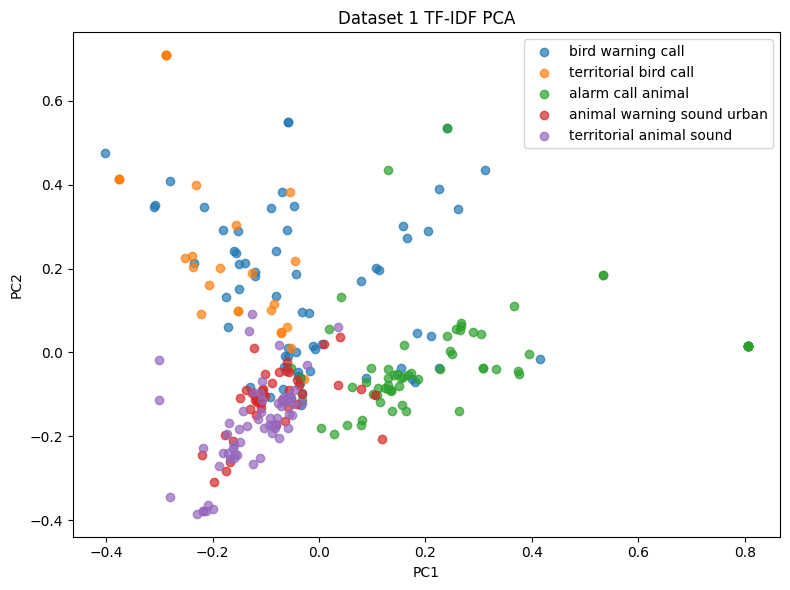

Saved file: .\outputs\plot_dataset1_tfidf_pca.png


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for query_name in df_tfidf_pca["query"].unique():
    subset = df_tfidf_pca[df_tfidf_pca["query"] == query_name]
    plt.scatter(subset["PC1"], subset["PC2"], label=query_name, alpha=0.7)

plt.title("Dataset 1 TF-IDF PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()

plot_pca_file = os.path.join(outputs_dir, "plot_dataset1_tfidf_pca.png")
plt.savefig(plot_pca_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_pca_file)

In [9]:
pca_csv_file = os.path.join(outputs_dir, "dataset1_tfidf_pca_points.csv")
df_tfidf_pca.to_csv(pca_csv_file, index=False, encoding="utf-8-sig")

print("Saved file:", pca_csv_file)

Saved file: .\outputs\dataset1_tfidf_pca_points.csv


In [10]:
%pip install sentence-transformers -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [12]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\ZZX\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ZZX\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [13]:
texts = df_text["text_for_vector"].tolist()

X_embed = embedding_model.encode(
    texts,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding matrix shape:", X_embed.shape)
print("First vector first 10 values:", X_embed[0][:10])

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Embedding matrix shape: (265, 384)
First vector first 10 values: [ 0.00156657 -0.04187041 -0.01251442 -0.01537986 -0.05729732 -0.01826397
  0.09682541 -0.07872248  0.06782246 -0.05988416]


In [14]:
from sklearn.decomposition import PCA

pca_embed = PCA(n_components=2, random_state=42)
X_embed_pca = pca_embed.fit_transform(X_embed)

df_embed_pca = pd.DataFrame({
    "PC1": X_embed_pca[:, 0],
    "PC2": X_embed_pca[:, 1],
    "query": df_text["query"].values,
    "title": df_text["title"].values
})

print("Embedding PCA explained variance ratio:", pca_embed.explained_variance_ratio_)
display(df_embed_pca.head(10))

Embedding PCA explained variance ratio: [0.09863632 0.06889842]


,PC1,PC2,query,title
0,0.157863,0.265376,bird warning call,White bellbird: listen to the world's loudest ...
1,0.490794,-0.177523,bird warning call,Bluebird Alarm Call
2,0.426604,-0.181364,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,0.371800,0.109248,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,0.473389,0.047038,bird warning call,Bird Calls: Is That An Alarm?
5,0.515482,-0.080946,bird warning call,Blackbird alarm call
6,0.191317,0.319555,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,0.331363,0.046251,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,0.044360,0.255844,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,0.226906,0.321499,bird warning call,Cardinal Bird-Calling Sounds promo


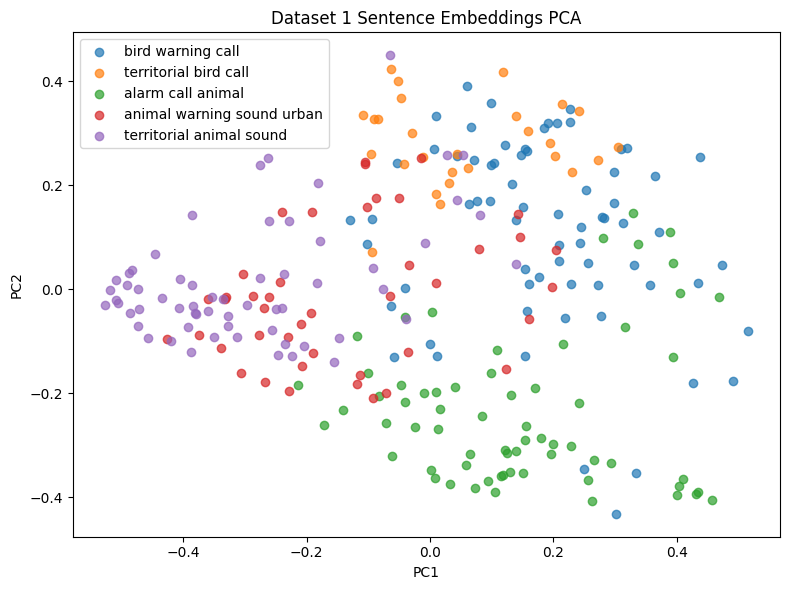

Saved file: .\outputs\plot_dataset1_sentence_embeddings_pca.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for query_name in df_embed_pca["query"].unique():
    subset = df_embed_pca[df_embed_pca["query"] == query_name]
    plt.scatter(subset["PC1"], subset["PC2"], label=query_name, alpha=0.7)

plt.title("Dataset 1 Sentence Embeddings PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()

plot_embed_pca_file = os.path.join(outputs_dir, "plot_dataset1_sentence_embeddings_pca.png")
plt.savefig(plot_embed_pca_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_embed_pca_file)

In [16]:
embed_pca_csv_file = os.path.join(outputs_dir, "dataset1_sentence_embeddings_pca_points.csv")
df_embed_pca.to_csv(embed_pca_csv_file, index=False, encoding="utf-8-sig")

print("Saved file:", embed_pca_csv_file)

Saved file: .\outputs\dataset1_sentence_embeddings_pca_points.csv


In [17]:
comparison_summary = pd.DataFrame([
    {
        "method": "TF-IDF",
        "vector_shape": str(X_tfidf.shape),
        "feature_dimension": X_tfidf.shape[1],
        "pca_pc1_variance": float(pca.explained_variance_ratio_[0]),
        "pca_pc2_variance": float(pca.explained_variance_ratio_[1]),
        "pca_total_2d_variance": float(pca.explained_variance_ratio_.sum()),
        "strength": "interpretable keywords, direct lexical matching",
        "limitation": "surface-level, weaker semantic grouping"
    },
    {
        "method": "Sentence Embeddings",
        "vector_shape": str(X_embed.shape),
        "feature_dimension": X_embed.shape[1],
        "pca_pc1_variance": float(pca_embed.explained_variance_ratio_[0]),
        "pca_pc2_variance": float(pca_embed.explained_variance_ratio_[1]),
        "pca_total_2d_variance": float(pca_embed.explained_variance_ratio_.sum()),
        "strength": "better semantic grouping, stronger cross-title similarity",
        "limitation": "less directly interpretable than TF-IDF"
    }
])

display(comparison_summary)

,method,vector_shape,feature_dimension,pca_pc1_variance,pca_pc2_variance,pca_total_2d_variance,strength,limitation
0,TF-IDF,"(265, 326)",326,0.052866,0.044682,0.097548,"interpretable keywords, direct lexical matching","surface-level, weaker semantic grouping"
1,Sentence Embeddings,"(265, 384)",384,0.098636,0.068898,0.167535,"better semantic grouping, stronger cross-title...",less directly interpretable than TF-IDF


In [18]:
comparison_file = os.path.join(outputs_dir, "dataset1_vectorisation_comparison_summary.csv")
comparison_summary.to_csv(comparison_file, index=False, encoding="utf-8-sig")

print("Saved file:", comparison_file)

Saved file: .\outputs\dataset1_vectorisation_comparison_summary.csv


In [19]:
comparison_note = f"""
Dataset 1 text vectorisation comparison:
TF-IDF produced a {X_tfidf.shape[0]} × {X_tfidf.shape[1]} matrix and was effective for direct lexical matching and interpretable keyword analysis.
Sentence embeddings produced a {X_embed.shape[0]} × {X_embed.shape[1]} matrix and showed clearer semantic grouping in PCA.
The first two PCA components explained {pca.explained_variance_ratio_.sum():.4f} of variance for TF-IDF and {pca_embed.explained_variance_ratio_.sum():.4f} for sentence embeddings.
Therefore, sentence embeddings are selected as the primary vectorisation method for Dataset 1, while TF-IDF is retained as a secondary method for interpretable term analysis.
""".strip()

print(comparison_note)

comparison_note_file = os.path.join(outputs_dir, "dataset1_vectorisation_comparison_note.txt")
with open(comparison_note_file, "w", encoding="utf-8") as f:
    f.write(comparison_note)

print("Saved file:", comparison_note_file)

Dataset 1 text vectorisation comparison:
TF-IDF produced a 265 × 326 matrix and was effective for direct lexical matching and interpretable keyword analysis.
Sentence embeddings produced a 265 × 384 matrix and showed clearer semantic grouping in PCA.
The first two PCA components explained 0.0975 of variance for TF-IDF and 0.1675 for sentence embeddings.
Therefore, sentence embeddings are selected as the primary vectorisation method for Dataset 1, while TF-IDF is retained as a secondary method for interpretable term analysis.
Saved file: .\outputs\dataset1_vectorisation_comparison_note.txt


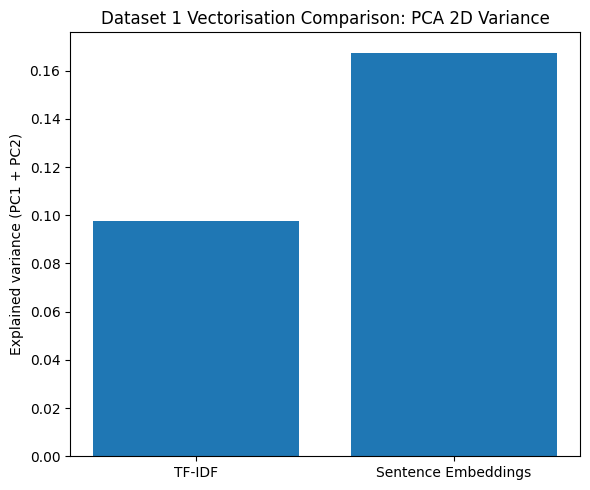

Saved file: .\outputs\plot_dataset1_vectorisation_comparison_variance.png


In [20]:
comparison_plot_df = pd.DataFrame({
    "method": ["TF-IDF", "Sentence Embeddings"],
    "PCA_2D_total_variance": [
        float(pca.explained_variance_ratio_.sum()),
        float(pca_embed.explained_variance_ratio_.sum())
    ]
})

plt.figure(figsize=(6, 5))
plt.bar(comparison_plot_df["method"], comparison_plot_df["PCA_2D_total_variance"])
plt.title("Dataset 1 Vectorisation Comparison: PCA 2D Variance")
plt.ylabel("Explained variance (PC1 + PC2)")
plt.tight_layout()

comparison_plot_file = os.path.join(outputs_dir, "plot_dataset1_vectorisation_comparison_variance.png")
plt.savefig(comparison_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", comparison_plot_file)

In [21]:
from sklearn.manifold import TSNE

In [22]:
tsne_tfidf = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tfidf_tsne = tsne_tfidf.fit_transform(X_tfidf_dense)

df_tfidf_tsne = pd.DataFrame({
    "TSNE1": X_tfidf_tsne[:, 0],
    "TSNE2": X_tfidf_tsne[:, 1],
    "query": df_text["query"].values,
    "title": df_text["title"].values
})

display(df_tfidf_tsne.head(10))

,TSNE1,TSNE2,query,title
0,-1.391452,-8.891320,bird warning call,White bellbird: listen to the world's loudest ...
1,3.961010,17.486694,bird warning call,Bluebird Alarm Call
2,-2.064297,21.803165,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,-2.343708,10.409479,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,-10.203612,11.654761,bird warning call,Bird Calls: Is That An Alarm?
5,3.693771,13.158566,bird warning call,Blackbird alarm call
6,-10.585436,10.454315,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,-10.311248,4.667127,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,17.048964,12.341932,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,-7.071943,-8.061677,bird warning call,Cardinal Bird-Calling Sounds promo


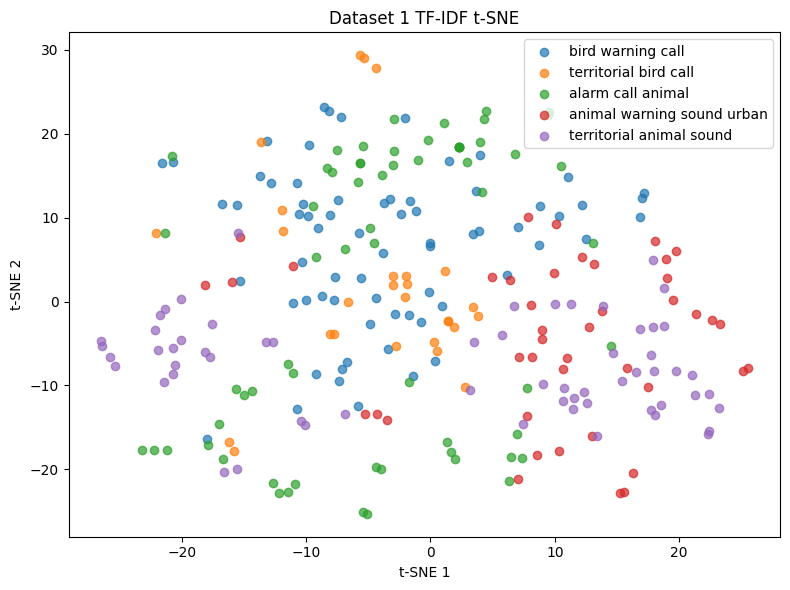

Saved file: .\outputs\plot_dataset1_tfidf_tsne.png


In [23]:
plt.figure(figsize=(8, 6))

for query_name in df_tfidf_tsne["query"].unique():
    subset = df_tfidf_tsne[df_tfidf_tsne["query"] == query_name]
    plt.scatter(subset["TSNE1"], subset["TSNE2"], label=query_name, alpha=0.7)

plt.title("Dataset 1 TF-IDF t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()

plot_tfidf_tsne_file = os.path.join(outputs_dir, "plot_dataset1_tfidf_tsne.png")
plt.savefig(plot_tfidf_tsne_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_tfidf_tsne_file)

In [24]:
tfidf_tsne_csv_file = os.path.join(outputs_dir, "dataset1_tfidf_tsne_points.csv")
df_tfidf_tsne.to_csv(tfidf_tsne_csv_file, index=False, encoding="utf-8-sig")

print("Saved file:", tfidf_tsne_csv_file)

Saved file: .\outputs\dataset1_tfidf_tsne_points.csv


In [25]:
tsne_embed = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_embed_tsne = tsne_embed.fit_transform(X_embed)

df_embed_tsne = pd.DataFrame({
    "TSNE1": X_embed_tsne[:, 0],
    "TSNE2": X_embed_tsne[:, 1],
    "query": df_text["query"].values,
    "title": df_text["title"].values
})

display(df_embed_tsne.head(10))

,TSNE1,TSNE2,query,title
0,6.935609,1.563053,bird warning call,White bellbird: listen to the world's loudest ...
1,-0.335144,12.925374,bird warning call,Bluebird Alarm Call
2,0.344126,16.005730,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,2.651161,11.121830,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,3.508945,7.409398,bird warning call,Bird Calls: Is That An Alarm?
5,0.681668,12.221304,bird warning call,Blackbird alarm call
6,8.359681,4.071932,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,0.110907,6.458086,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,3.844284,-3.698744,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,7.230793,2.884701,bird warning call,Cardinal Bird-Calling Sounds promo


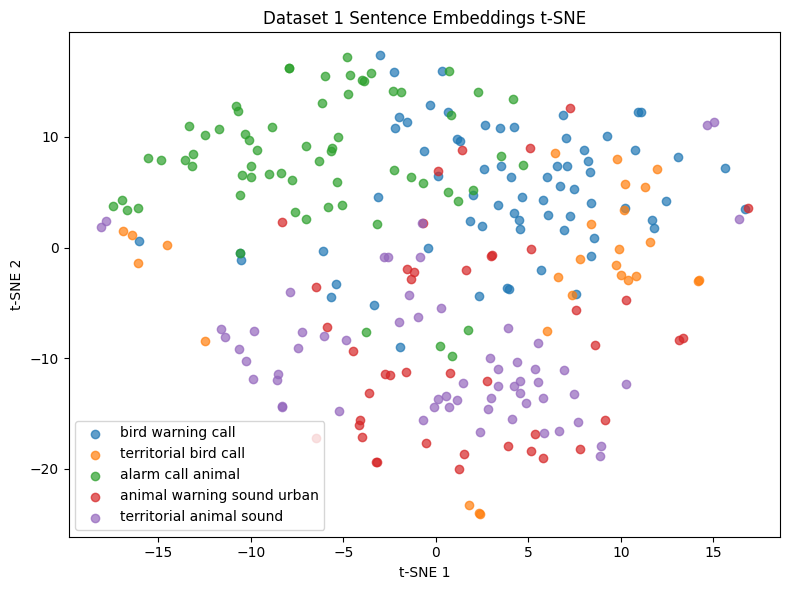

Saved file: .\outputs\plot_dataset1_sentence_embeddings_tsne.png


In [26]:
plt.figure(figsize=(8, 6))

for query_name in df_embed_tsne["query"].unique():
    subset = df_embed_tsne[df_embed_tsne["query"] == query_name]
    plt.scatter(subset["TSNE1"], subset["TSNE2"], label=query_name, alpha=0.7)

plt.title("Dataset 1 Sentence Embeddings t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()

plot_embed_tsne_file = os.path.join(outputs_dir, "plot_dataset1_sentence_embeddings_tsne.png")
plt.savefig(plot_embed_tsne_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_embed_tsne_file)

In [27]:
embed_tsne_csv_file = os.path.join(outputs_dir, "dataset1_sentence_embeddings_tsne_points.csv")
df_embed_tsne.to_csv(embed_tsne_csv_file, index=False, encoding="utf-8-sig")

print("Saved file:", embed_tsne_csv_file)

Saved file: .\outputs\dataset1_sentence_embeddings_tsne_points.csv


In [28]:
comparison_note_v2 = f"""
Dataset 1 text vectorisation comparison:
TF-IDF produced a {X_tfidf.shape[0]} × {X_tfidf.shape[1]} matrix and was useful for interpretable keyword matching.
Sentence embeddings produced a {X_embed.shape[0]} × {X_embed.shape[1]} matrix and preserved broader semantic similarity between titles.

In PCA, the first two components explained {pca.explained_variance_ratio_.sum():.4f} of variance for TF-IDF and {pca_embed.explained_variance_ratio_.sum():.4f} for sentence embeddings.
In visual inspection, TF-IDF showed partial separation by repeated lexical patterns, while sentence embeddings showed clearer semantic grouping across query families.

Therefore, sentence embeddings are selected as the primary vectorisation method for Dataset 1.
TF-IDF is retained as a secondary comparison method for interpretable term-level analysis.
""".strip()

print(comparison_note_v2)

comparison_note_v2_file = os.path.join(outputs_dir, "dataset1_vectorisation_comparison_note_v2.txt")
with open(comparison_note_v2_file, "w", encoding="utf-8") as f:
    f.write(comparison_note_v2)

print("Saved file:", comparison_note_v2_file)

Dataset 1 text vectorisation comparison:
TF-IDF produced a 265 × 326 matrix and was useful for interpretable keyword matching.
Sentence embeddings produced a 265 × 384 matrix and preserved broader semantic similarity between titles.

In PCA, the first two components explained 0.0975 of variance for TF-IDF and 0.1675 for sentence embeddings.
In visual inspection, TF-IDF showed partial separation by repeated lexical patterns, while sentence embeddings showed clearer semantic grouping across query families.

Therefore, sentence embeddings are selected as the primary vectorisation method for Dataset 1.
TF-IDF is retained as a secondary comparison method for interpretable term-level analysis.
Saved file: .\outputs\dataset1_vectorisation_comparison_note_v2.txt


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
cluster_eval_rows = []

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_embed)

    silhouette = silhouette_score(X_embed, labels)

    cluster_eval_rows.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette
    })

df_cluster_eval = pd.DataFrame(cluster_eval_rows)
display(df_cluster_eval)

,k,inertia,silhouette_score
0,3,149.579132,0.063816
1,4,145.841583,0.064079
2,5,142.469818,0.054935
3,6,138.971725,0.055742
4,7,136.925034,0.052119
5,8,134.531403,0.042275


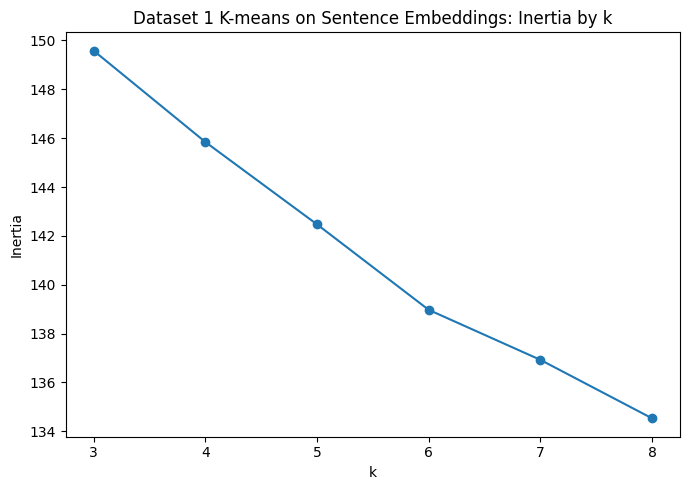

Saved file: .\outputs\plot_dataset1_kmeans_inertia_by_k.png


In [31]:
plt.figure(figsize=(7, 5))
plt.plot(df_cluster_eval["k"], df_cluster_eval["inertia"], marker="o")
plt.title("Dataset 1 K-means on Sentence Embeddings: Inertia by k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()

plot_inertia_file = os.path.join(outputs_dir, "plot_dataset1_kmeans_inertia_by_k.png")
plt.savefig(plot_inertia_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_inertia_file)

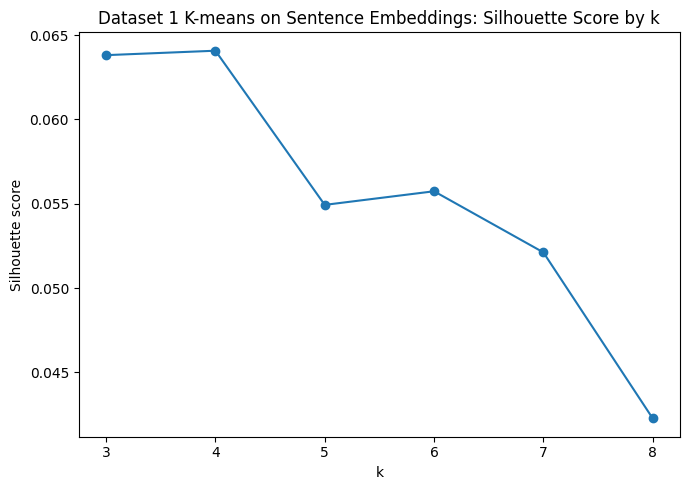

Saved file: .\outputs\plot_dataset1_kmeans_silhouette_by_k.png


In [32]:
plt.figure(figsize=(7, 5))
plt.plot(df_cluster_eval["k"], df_cluster_eval["silhouette_score"], marker="o")
plt.title("Dataset 1 K-means on Sentence Embeddings: Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()

plot_silhouette_file = os.path.join(outputs_dir, "plot_dataset1_kmeans_silhouette_by_k.png")
plt.savefig(plot_silhouette_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_silhouette_file)

In [33]:
best_k = int(df_cluster_eval.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Best k by silhouette score:", best_k)

Best k by silhouette score: 4


In [34]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_embed)

df_embed_cluster = df_text.copy()
df_embed_cluster["cluster"] = cluster_labels

print("Rows:", len(df_embed_cluster))
display(df_embed_cluster[["query", "title", "cluster"]].head(20))

Rows: 265


,query,title,cluster
0,bird warning call,White bellbird: listen to the world's loudest ...,3
1,bird warning call,Bluebird Alarm Call,1
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),1
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",3
4,bird warning call,Bird Calls: Is That An Alarm?,1
5,bird warning call,Blackbird alarm call,1
6,bird warning call,Decoding bird calls: What they are REALLY Saying?,3
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...,3
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...,3
9,bird warning call,Cardinal Bird-Calling Sounds promo,3


In [35]:
cluster_query_crosstab = pd.crosstab(
    df_embed_cluster["cluster"],
    df_embed_cluster["query"]
)

display(cluster_query_crosstab)

query,alarm call animal,animal warning sound urban,bird warning call,territorial animal sound,territorial bird call
cluster,,,,,
0,5,19,0,40,0
1,51,1,13,0,0
2,5,10,9,14,1
3,4,13,47,7,26


In [36]:
cluster_query_file = os.path.join(outputs_dir, "dataset1_cluster_query_crosstab.csv")
cluster_query_crosstab.to_csv(cluster_query_file, encoding="utf-8-sig")

print("Saved file:", cluster_query_file)

Saved file: .\outputs\dataset1_cluster_query_crosstab.csv


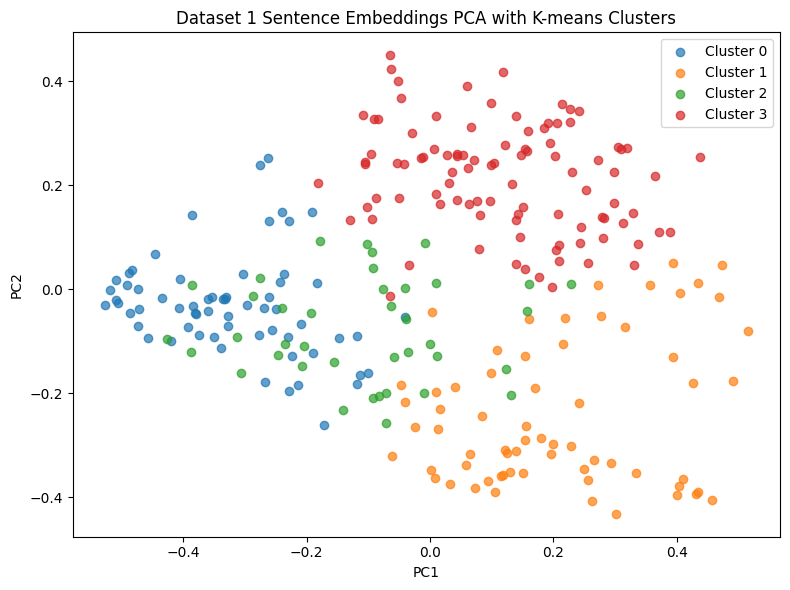

Saved file: .\outputs\plot_dataset1_sentence_embeddings_pca_clusters.png


In [37]:
df_embed_pca_cluster = df_embed_pca.copy()
df_embed_pca_cluster["cluster"] = cluster_labels

plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_embed_pca_cluster["cluster"].unique()):
    subset = df_embed_pca_cluster[df_embed_pca_cluster["cluster"] == cluster_id]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.title("Dataset 1 Sentence Embeddings PCA with K-means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()

plot_cluster_pca_file = os.path.join(outputs_dir, "plot_dataset1_sentence_embeddings_pca_clusters.png")
plt.savefig(plot_cluster_pca_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_cluster_pca_file)

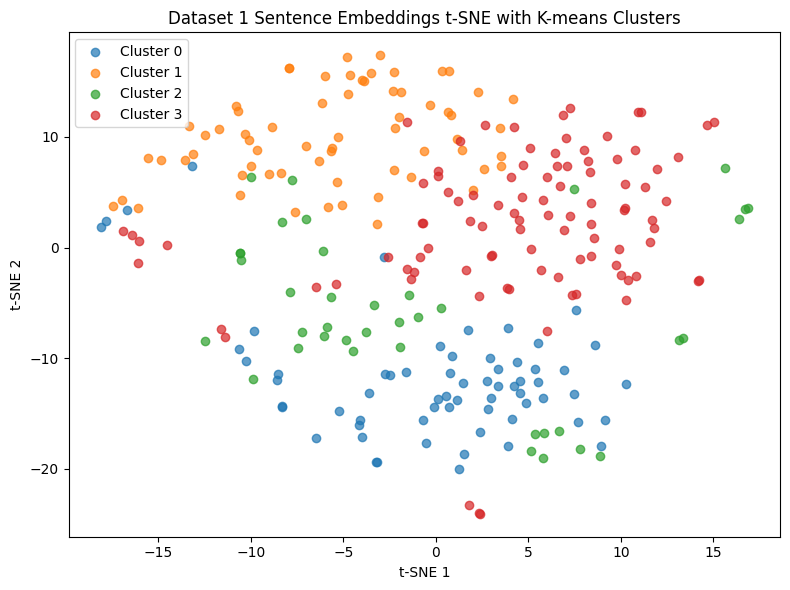

Saved file: .\outputs\plot_dataset1_sentence_embeddings_tsne_clusters.png


In [38]:
df_embed_tsne_cluster = df_embed_tsne.copy()
df_embed_tsne_cluster["cluster"] = cluster_labels

plt.figure(figsize=(8, 6))

for cluster_id in sorted(df_embed_tsne_cluster["cluster"].unique()):
    subset = df_embed_tsne_cluster[df_embed_tsne_cluster["cluster"] == cluster_id]
    plt.scatter(subset["TSNE1"], subset["TSNE2"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.title("Dataset 1 Sentence Embeddings t-SNE with K-means Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()

plot_cluster_tsne_file = os.path.join(outputs_dir, "plot_dataset1_sentence_embeddings_tsne_clusters.png")
plt.savefig(plot_cluster_tsne_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_cluster_tsne_file)

In [39]:
cluster_output_file = os.path.join(outputs_dir, "dataset1_sentence_embeddings_clusters.csv")
df_embed_cluster.to_csv(cluster_output_file, index=False, encoding="utf-8-sig")

print("Saved file:", cluster_output_file)

Saved file: .\outputs\dataset1_sentence_embeddings_clusters.csv


In [40]:
cluster_name_map = {
    0: "territorial_animal_presence",
    1: "alarm_response_animals",
    2: "mixed_transition_signals",
    3: "bird_warning_and_territorial_calls"
}

df_embed_cluster["cluster_name"] = df_embed_cluster["cluster"].map(cluster_name_map)

display(df_embed_cluster[["query", "title", "cluster", "cluster_name"]].head(20))

,query,title,cluster,cluster_name
0,bird warning call,White bellbird: listen to the world's loudest ...,3,bird_warning_and_territorial_calls
1,bird warning call,Bluebird Alarm Call,1,alarm_response_animals
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),1,alarm_response_animals
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",3,bird_warning_and_territorial_calls
4,bird warning call,Bird Calls: Is That An Alarm?,1,alarm_response_animals
5,bird warning call,Blackbird alarm call,1,alarm_response_animals
6,bird warning call,Decoding bird calls: What they are REALLY Saying?,3,bird_warning_and_territorial_calls
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...,3,bird_warning_and_territorial_calls
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...,3,bird_warning_and_territorial_calls
9,bird warning call,Cardinal Bird-Calling Sounds promo,3,bird_warning_and_territorial_calls


In [41]:
cluster_examples = (
    df_embed_cluster[["cluster", "cluster_name", "query", "title"]]
    .groupby(["cluster", "cluster_name", "query"], group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

display(cluster_examples)

,cluster,cluster_name,query,title
0,3,bird_warning_and_territorial_calls,bird warning call,White bellbird: listen to the world's loudest ...
1,1,alarm_response_animals,bird warning call,Bluebird Alarm Call
2,1,alarm_response_animals,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,3,bird_warning_and_territorial_calls,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,1,alarm_response_animals,bird warning call,Bird Calls: Is That An Alarm?
5,3,bird_warning_and_territorial_calls,bird warning call,Decoding bird calls: What they are REALLY Saying?
6,2,mixed_transition_signals,bird warning call,Northern Flicker Calls Explained (4 Sounds & W...
7,2,mixed_transition_signals,bird warning call,red-tailed hawk screaming
8,2,mixed_transition_signals,bird warning call,Why Budgies Make Distress Calls (and What They...
9,3,bird_warning_and_territorial_calls,territorial bird call,Nuthatch Bird Call


In [42]:
cluster_examples_file = os.path.join(outputs_dir, "dataset1_cluster_examples.csv")
cluster_examples.to_csv(cluster_examples_file, index=False, encoding="utf-8-sig")

print("Saved file:", cluster_examples_file)

Saved file: .\outputs\dataset1_cluster_examples.csv


In [43]:
ml_note = """
Dataset 1 computational analysis:
Sentence embeddings were selected as the primary vectorisation method because they showed clearer semantic grouping than TF-IDF in both PCA and t-SNE visualisation.

K-means clustering was then applied to the sentence embeddings.
The best cluster number was selected using silhouette score, with k = 4 giving the highest score among the tested values.

The resulting four clusters broadly correspond to:
(1) territorial animal presence,
(2) alarm response animals,
(3) mixed transition signals,
and (4) bird warning and territorial calls.

This shows that the dataset is not only grouped by the original scraping queries, but can also be reorganised into semantically meaningful sound-boundary categories.
These cluster families can be used later as higher-level design categories for cross-domain mapping and fragment generation.
""".strip()

print(ml_note)

ml_note_file = os.path.join(outputs_dir, "dataset1_ml_clustering_note.txt")
with open(ml_note_file, "w", encoding="utf-8") as f:
    f.write(ml_note)

print("Saved file:", ml_note_file)

Dataset 1 computational analysis:
Sentence embeddings were selected as the primary vectorisation method because they showed clearer semantic grouping than TF-IDF in both PCA and t-SNE visualisation.

K-means clustering was then applied to the sentence embeddings.
The best cluster number was selected using silhouette score, with k = 4 giving the highest score among the tested values.

The resulting four clusters broadly correspond to:
(1) territorial animal presence,
(2) alarm response animals,
(3) mixed transition signals,
and (4) bird warning and territorial calls.

This shows that the dataset is not only grouped by the original scraping queries, but can also be reorganised into semantically meaningful sound-boundary categories.
These cluster families can be used later as higher-level design categories for cross-domain mapping and fragment generation.
Saved file: .\outputs\dataset1_ml_clustering_note.txt
